In [5]:
import matplotlib.pyplot as plt
import osmnx as ox
ox.settings.use_cache = False
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
import networkx as nx

Average longitude and latitude from Crime Data

In [6]:
# Chicago
point = (41.823, -87.671)

Graph nodes from 2 km radius around point (use dist = 2000)

In [7]:
G = ox.graph_from_point(point, dist=2000, network_type='drive')

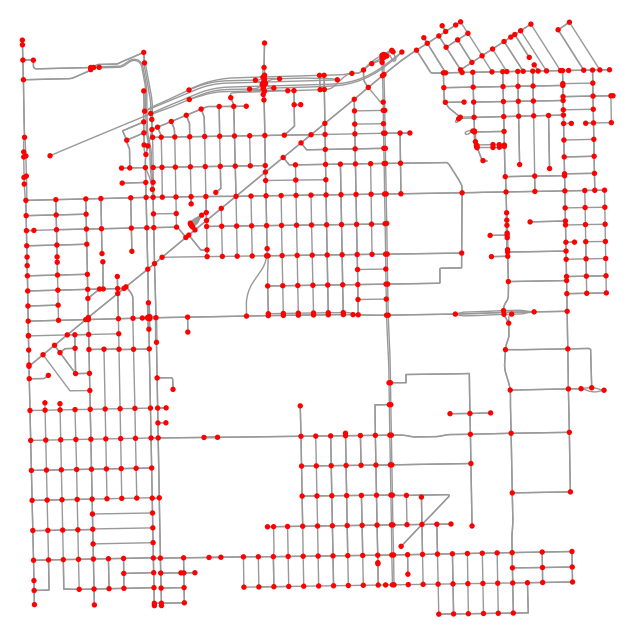

In [8]:
fig, ax = ox.plot_graph(G, node_color='r', edge_color='#999999', bgcolor='w')

Nodes dataset describing crime location (x,y) and type of node (highway, traffic signal, junction, etc)

In [9]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.head(5)

,y,x,highway,ref,street_count,junction,railway,geometry
osmid,,,,,,,,
25779221,41.837422,-87.669478,motorway_junction,290,3,NaN,NaN,POINT (-87.66948 41.83742)
26098045,41.839102,-87.664226,NaN,NaN,3,NaN,NaN,POINT (-87.66423 41.8391)
256180881,41.839215,-87.663035,NaN,NaN,3,NaN,NaN,POINT (-87.66303 41.83921)
256180894,41.808494,-87.677115,traffic_signals,NaN,3,NaN,NaN,POINT (-87.67712 41.80849)
256180895,41.808436,-87.681986,NaN,NaN,3,NaN,NaN,POINT (-87.68199 41.80844)


Create dataframe of crime statistics

In [11]:
# Import csv of crimeData from github
df = pd.read_csv("ChicagoCrimeData.csv")
# Drop irrelevant columns
df = df.drop(columns=['uid', 'address', 'city_name', 'offense_code', 'offense_type', 'date_single', 'location_category', 'fips_state',
                      'fips_county', 'tract', 'block_group', 'block'])
df.head(5)

,longitude,latitude,location_type
0,-87.751482,41.894009,street
1,-87.710383,41.752417,residence
2,-87.607485,41.723546,street
3,-87.570235,41.751678,street
4,-87.570235,41.751678,street


Turn data frames into GeoDataFrames

In [13]:
gdf_crime = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

Link points of interest to nearest node on graph;

Relating crime dataset to type of location at node

In [14]:
# We use 'sjoin_nearest' because POIs might not be exactly on the node coordinates
nodes_with_pois = gpd.sjoin_nearest(nodes, gdf_crime, how="left", distance_col="dist")
nodes_with_pois.head(5)

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,y,x,highway,ref,street_count,junction,railway,geometry,index_right,longitude,latitude,location_type,dist
osmid,,,,,,,,,,,,,
25779221,41.837422,-87.669478,motorway_junction,290,3,NaN,NaN,POINT (-87.66948 41.83742),144,-87.659655,41.837862,street,0.009833
26098045,41.839102,-87.664226,NaN,NaN,3,NaN,NaN,POINT (-87.66423 41.8391),144,-87.659655,41.837862,street,0.004736
256180881,41.839215,-87.663035,NaN,NaN,3,NaN,NaN,POINT (-87.66303 41.83921),144,-87.659655,41.837862,street,0.003641
256180894,41.808494,-87.677115,traffic_signals,NaN,3,NaN,NaN,POINT (-87.67712 41.80849),53,-87.674818,41.808509,vehicle parking,0.002297
256180895,41.808436,-87.681986,NaN,NaN,3,NaN,NaN,POINT (-87.68199 41.80844),292,-87.684442,41.808924,street,0.002504


Count points of interest by category for each node

In [15]:
poi_counts = nodes_with_pois.groupby([nodes_with_pois.index, 'location_type']).size().unstack(fill_value=0)
poi_counts.head(5)

location_type,green space,other open space,private vehicle,residence,street,vehicle parking
osmid,,,,,,
25779221,0,0,0,0,1,0
26098045,0,0,0,0,1,0
256180881,0,0,0,0,1,0
256180894,0,0,0,0,0,1
256180895,0,0,0,0,1,0


Aggregate

In [16]:
nodes_with_crime = gpd.sjoin_nearest(nodes, gdf_crime, how="left")
crime_counts = nodes_with_crime.groupby(nodes_with_crime.index).size()

/usr/local/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


Build final feature matrix X

In [18]:
# Merge the crime counts and POI categories
X_df = pd.merge(poi_counts, crime_counts.to_frame('crime_count'), left_index=True, right_index=True, how='right').fillna(0)
X_df.head(5)

,green space,other open space,private vehicle,residence,street,vehicle parking,crime_count
osmid,,,,,,,
25779221,0,0,0,0,1,0,1
26098045,0,0,0,0,1,0,1
256180881,0,0,0,0,1,0,1
256180894,0,0,0,0,0,1,1
256180895,0,0,0,0,1,0,1


Turn points into Z-scores to get standardized version of matrix

In [22]:
# StandardScaler() turns points into Z-scores
scaler = StandardScaler()
X_matrix = scaler.fit_transform(X_df)
# Numbers represent "hot spots" for crime
X_matrix[:5]

array([[-0.07570112, -0.57186724, -0.24581082, -0.21854335,  0.76930926,
        -0.13187609, -0.07570112],
       [-0.07570112, -0.57186724, -0.24581082, -0.21854335,  0.76930926,
        -0.13187609, -0.07570112],
       [-0.07570112, -0.57186724, -0.24581082, -0.21854335,  0.76930926,
        -0.13187609, -0.07570112],
       [-0.07570112, -0.57186724, -0.24581082, -0.21854335, -1.29986737,
         7.58287544, -0.07570112],
       [-0.07570112, -0.57186724, -0.24581082, -0.21854335,  0.76930926,
        -0.13187609, -0.07570112]])

In [23]:
# M x N matrix
# N different types of places
# N data points
X_matrix.shape

(702, 7)

Analyzing output; See what types of places have most common crime clustering

In [24]:
# Insert code to bring back in matrix labels of location_type and to take see what to do with z scores